In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
import sys
import os
from tqdm import tqdm

project_root = os.path.dirname(os.path.abspath(''))
if project_root not in sys.path:
    sys.path.append(project_root)

from FEATURES.features import *
from MODELS.pipeline import *
from MODELS.xgboostModel import *

/Users/alexg/Documents/Documents/Prize-Picks-Prop-Predictor/myenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
pd.set_option('display.max_columns', None)

s19 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_19.csv')
s20 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_20.csv')
s21 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_21.csv')
s22 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_22.csv')
s23 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_23.csv')
s24 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_24.csv')
s25 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_25.csv')
# s26 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_26.csv')

s25_firstHalf = s25[s25['GAME_DATE'] < '2025-01-15']
s25_secondHalf = s25[s25['GAME_DATE'] >= '2025-01-15']

train_df = pd.concat([s19,s20,s21,s22,s23,s24])
val_df = s25_firstHalf
test_df = s25_secondHalf

print(f"Training data shape: {train_df.shape}")
print(f"Training date range: {train_df['GAME_DATE'].min()} to {train_df['GAME_DATE'].max()}")
print(f"Validation data shape: {val_df.shape}")
print(f"Validation date range: {val_df['GAME_DATE'].min()} to {val_df['GAME_DATE'].max()}")
print(f"Test data shape: {test_df.shape}")
print(f"Test date range: {test_df['GAME_DATE'].min()} to {test_df['GAME_DATE'].max()}")
test_df.tail()

Training data shape: (149636, 776)
Training date range: 2018-10-17 to 2024-04-14
Validation data shape: (12580, 769)
Validation date range: 2024-10-23 to 2025-01-14
Test data shape: (13684, 769)
Test date range: 2025-01-15 to 2025-04-13


,Unnamed: 0,Unnamed: 0.2,PLAYER_NAME,PLAYER_ID,MATCHUP,TEAM_ABBREVIATION,TEAM_ID,OPP_ABBREVIATION,HOME_GAME,GAME_ID,GAME_DATE,WL,PTS,AST,REB,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,STL,BLK,TOV,PLUS_MINUS,FANTASY_PTS,POINT_PER_SHOT,EFG,START_POSITION,COMMENT,E_OFF_RATING,E_DEF_RATING,NET_RATING,OREB_PCT,DREB_PCT,REB_PCT,AST_PCT,EFG_PCT,AST_TOV,USG_PCT,TS_PCT,E_PACE,PACE,PIE,POSS,PACE_PER40,E_USG_PCT,MIN,SPD,DIST,ORBC,DRBC,RBC,TCHS,SAST,FTAST,PASS,CFGM,CFGA,CFG_PCT,UFGM,UFGA,UFG_PCT,DFGM,DFGA,DFG_PCT,PTS_OFF_TOV,PTS_2ND_CHANCE,PTS_FB,PTS_PAINT,OPP_PTS_OFF_TOV,OPP_PTS_2ND_CHANCE,OPP_PTS_FB,OPP_PTS_PAINT,BLKA,PF,PFD,IS_PLAYOFF,TEAM_SEASON_ID_x,whos_favored,spread,total,team_is_favored,team_spread,OPP_BLOWOUT_RISK,TEAM_NAME,TEAM_MIN,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_STL,TEAM_BLK,TEAM_TOV,TEAM_PF,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_PACE,GAME_PACE,OPP_PACE,OPP_TEAM_ID,TEAM_OFF_RATING,TEAM_DEF_RATING,OPP_DEF_RATING,OPP_OFF_RATING,OPP_PTS,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_REB,OPP_AST,OPP_STL,OPP_BLK,OPP_TOV,percentageFieldGoalsAttempted2pt,percentageFieldGoalsAttempted3pt,percentagePoints2pt,percentagePointsMidrange2pt,percentagePoints3pt,percentagePointsFastBreak,percentagePointsFreeThrow,percentagePointsOffTurnovers,percentagePointsPaint,percentageAssisted2pt,percentageUnassisted2pt,percentageAssisted3pt,percentageUnassisted3pt,percentageAssistedFGM,percentageUnassistedFGM,matchupFieldGoalsMade,matchupFieldGoalsAttempted,matchupThreePointersMade,matchupThreePointersAttempted,playerPoints,matchupMinutes,DEF_FG_PCT_ALLOWED,DEF_3PT_PCT_ALLOWED,PTS_ALLOWED_PER_MIN,AGE,FREQ_FG3,FG3M_main,FG3A_main,FG3_PCT_main,NS_FG3_PCT,PLUS_MINUS_FG3,FREQ_FG2,FG2M,FG2A,FG2_PCT,NS_FG2_PCT,PLUS_MINUS_FG2,FREQ_LT_06,FGM_LT_06,FGA_LT_06,LT_06_PCT,NS_LT_06_PCT,PLUS_MINUS_LT_06,FREQ_LT_10,FGM_LT_10,FGA_LT_10,LT_10_PCT,NS_LT_10_PCT,PLUS_MINUS_LT_10,FREQ_GT_15,FGM_GT_15,FGA_GT_15,GT_15_PCT,NS_GT_15_PCT,PLUS_MINUS_GT_15,DEF_TOV_FORCED_PER_MIN,DEF_BLOCKS_PER_MIN,DEF_SHOOTING_FOULS_PER_MIN,DEF_AST_ALLOWED_PER_MIN,STARTING,BLOWOUT_RISK,COMPETITIVE_GAME,TEAM_IMPLIED_PTS,HEIGHT,WEIGHT,GUARD,FORWARD,CENTER,TEAM_DAYS_REST,PLAYER_DAYS_REST,TEAM_B2B,IS_BACK_TO_BACK,PLAYER_MISSED_LAST,PTS_ROLLING_AVG_5,AST_ROLLING_AVG_5,FGA_ROLLING_AVG_5,FG3A_ROLLING_AVG_5,FTA_ROLLING_AVG_5,TOV_ROLLING_AVG_5,FG_PCT_ROLLING_AVG_5,TS_PCT_ROLLING_AVG_5,USG_PCT_ROLLING_AVG_5,MIN_ROLLING_AVG_5,PACE_ROLLING_AVG_5,PIE_ROLLING_AVG_5,E_OFF_RATING_ROLLING_AVG_5,NET_RATING_ROLLING_AVG_5,TCHS_ROLLING_AVG_5,POSS_ROLLING_AVG_5,EFG_PCT_ROLLING_AVG_5,percentagePointsPaint_ROLLING_AVG_5,percentagePointsMidrange2pt_ROLLING_AVG_5,percentagePoints3pt_ROLLING_AVG_5,percentagePointsFreeThrow_ROLLING_AVG_5,PF_ROLLING_AVG_5,PTS_ROLLING_AVG_7,AST_ROLLING_AVG_7,FGA_ROLLING_AVG_7,FG3A_ROLLING_AVG_7,FTA_ROLLING_AVG_7,TOV_ROLLING_AVG_7,FG_PCT_ROLLING_AVG_7,TS_PCT_ROLLING_AVG_7,USG_PCT_ROLLING_AVG_7,MIN_ROLLING_AVG_7,PACE_ROLLING_AVG_7,PIE_ROLLING_AVG_7,E_OFF_RATING_ROLLING_AVG_7,NET_RATING_ROLLING_AVG_7,TCHS_ROLLING_AVG_7,POSS_ROLLING_AVG_7,EFG_PCT_ROLLING_AVG_7,percentagePointsPaint_ROLLING_AVG_7,percentagePointsMidrange2pt_ROLLING_AVG_7,percentagePoints3pt_ROLLING_AVG_7,percentagePointsFreeThrow_ROLLING_AVG_7,PF_ROLLING_AVG_7,PTS_ROLLING_AVG_10,AST_ROLLING_AVG_10,FGA_ROLLING_AVG_10,FG3A_ROLLING_AVG_10,FTA_ROLLING_AVG_10,TOV_ROLLING_AVG_10,FG_PCT_ROLLING_AVG_10,TS_PCT_ROLLING_AVG_10,USG_PCT_ROLLING_AVG_10,MIN_ROLLING_AVG_10,PACE_ROLLING_AVG_10,PIE_ROLLING_AVG_10,E_OFF_RATING_ROLLING_AVG_10,NET_RATING_ROLLING_AVG_10,TCHS_ROLLING_AVG_10,POSS_ROLLING_AVG_10,EFG_PCT_ROLLING_AVG_10,percentagePointsPaint_ROLLING_AVG_10,percentagePointsMidrange2pt_ROLLING_AVG_10,percentagePoints3pt_ROLLING_AVG_10,percentagePointsFreeThrow_ROLLING_AVG_10,PF_ROLLING_AVG_10,PTS_ROLLING_AVG_15,AST_ROLLING_AVG_15,FGA_ROLLING_AVG_15,FG3A_ROLLING_AVG_15,FTA_ROLLING_AVG_15,TOV_ROLLING_AVG_15,FG_PCT_ROLLING_AVG_15,TS_PCT_ROLLING_AVG_15,USG

In [20]:
top_features = [
    'HOME_GAME',
    'STARTING',
    'PLAYER_IS_TEAM_STAR',
    'STAR_SAT_OUT',
    'IS_BACK_TO_BACK',
    'PLAYER_DAYS_REST',
    
    'MIN_LAG_1',
    'MIN_VOLATILITY_5_TO_DATE',
    'MIN_VOLATILITY_10_TO_DATE',
    'percentagePointsMidrange2pt_AVG_TO_DATE',
    'percentagePointsPaint_AVG_TO_DATE',
    'PTS_DELTA_STAR_OUT',
    'MATCHUP_AVG_USG_PCT_LAST_3_TO_DATE',
    'PTS_ROLLING_AVG_25',
    'PTS_PER_MIN_X_USG',
    'PTS_LAG_2',
    'PTS_VOLATILITY_25_TO_DATE',
    'PTS_EXTREME_VOLATILITY',
    'PTS_RECENT_HIGH_VOLATILITY',
    'FGA_LAG_1',
    'FGA_VOLATILITY_10_TO_DATE',
    'MATCHUP_AVG_FGA_LAST_3_TO_DATE',
    'FTA_ROLLING_AVG_40',
    'FT_RATE_ROLLING_AVG_5',
    '3PA_SHARE',
    'USG_PCT_LAG_1',
    'USG_PCT_ROLLING_AVG_25',
    'USG_PCT_VOLATILITY_5_TO_DATE',
    'TS_PCT_ROLLING_AVG_25',
    'TS_PCT_VOLATILITY_10_TO_DATE',
    'PIE_AVG_TO_DATE',
    'E_OFF_RATING_AVG_TO_DATE',
    'NET_RATING_AVG_TO_DATE',
    'TCHS_ROLLING_AVG_10',
    'TOV_ROLLING_AVG_10',
    'FG_PCT_AVG_TO_DATE',
    'PF_ROLLING_AVG_5',

    'TEAM_OFF_RATING_AVG_TO_DATE',
    'TEAM_PACE_AVG_TO_DATE',
    'TEAM_PTS_ROLLING_AVG_3',
    'TEAM_AST_ROLLING_AVG_3',

    'OPP_DEF_RATING_AVG_TO_DATE',
    'OPP_PACE_AVG_TO_DATE',
    'OPP_BLK_AVG_TO_DATE',
    'OPP_TOV_AVG_TO_DATE',
    'OPP_GUARD_DEF_RATING',
    'OPP_GUARD_DEF_FG_PCT_ALLOWED',
    'OPP_GUARD_DEF_3PT_PCT_ALLOWED',
    'OPP_GUARD_PTS_ALLOWED_PER_MIN',
    'OPP_FORWARD_DEF_RATING',
    'OPP_FORWARD_DEF_FG_PCT_ALLOWED',
    'OPP_FORWARD_DEF_3PT_PCT_ALLOWED',
    'OPP_FORWARD_PTS_ALLOWED_PER_MIN',
    'OPP_CENTER_DEF_RATING',
    'OPP_CENTER_DEF_FG_PCT_ALLOWED',
    'OPP_CENTER_DEF_3PT_PCT_ALLOWED',
    'OPP_CENTER_PTS_ALLOWED_PER_MIN',
    'PTS_PER_MIN_X_OPP_DEF_RATING',

    'PLAYER_HOME_PTS_DELTA',
    'PLAYER_AWAY_PTS_DELTA',
    'PLAYER_HOME_USG_PCT_DELTA',
    'PLAYER_AWAY_USG_PCT_DELTA',
    'PLAYER_HOME_FGA_DELTA',
    'PLAYER_AWAY_FGA_DELTA',
    'PLAYER_HOME_FTA_DELTA',
    'PLAYER_AWAY_FTA_DELTA',
    'MATCHUP_PTS_DELTA_LAST_3',
    'MATCHUP_FGA_DELTA_LAST_3',
    'MATCHUP_USG_PCT_DELTA_LAST_3',
    'MATCHUP_EFG_PCT_DELTA_LAST_3'
 ]

In [59]:
# columns = train_df.columns.tolist()
# guardIDX = columns.index('CENTER')
# features = columns[guardIDX + 1:]
# newFeatures = features

In [60]:
# selected_features, top_features = select_features_xgb_importance(
#     train_df[newFeatures],
#     train_df['PTS'],
#     top_n=50,                 # increase if you want more coverage
#     n_runs=5,                 # stabilizes importance ranking
#     include_context=False,     # adds game context
#     validate_permutation=False # prunes noise
# )

# XGBOOST MODEL

### Remove correlated features

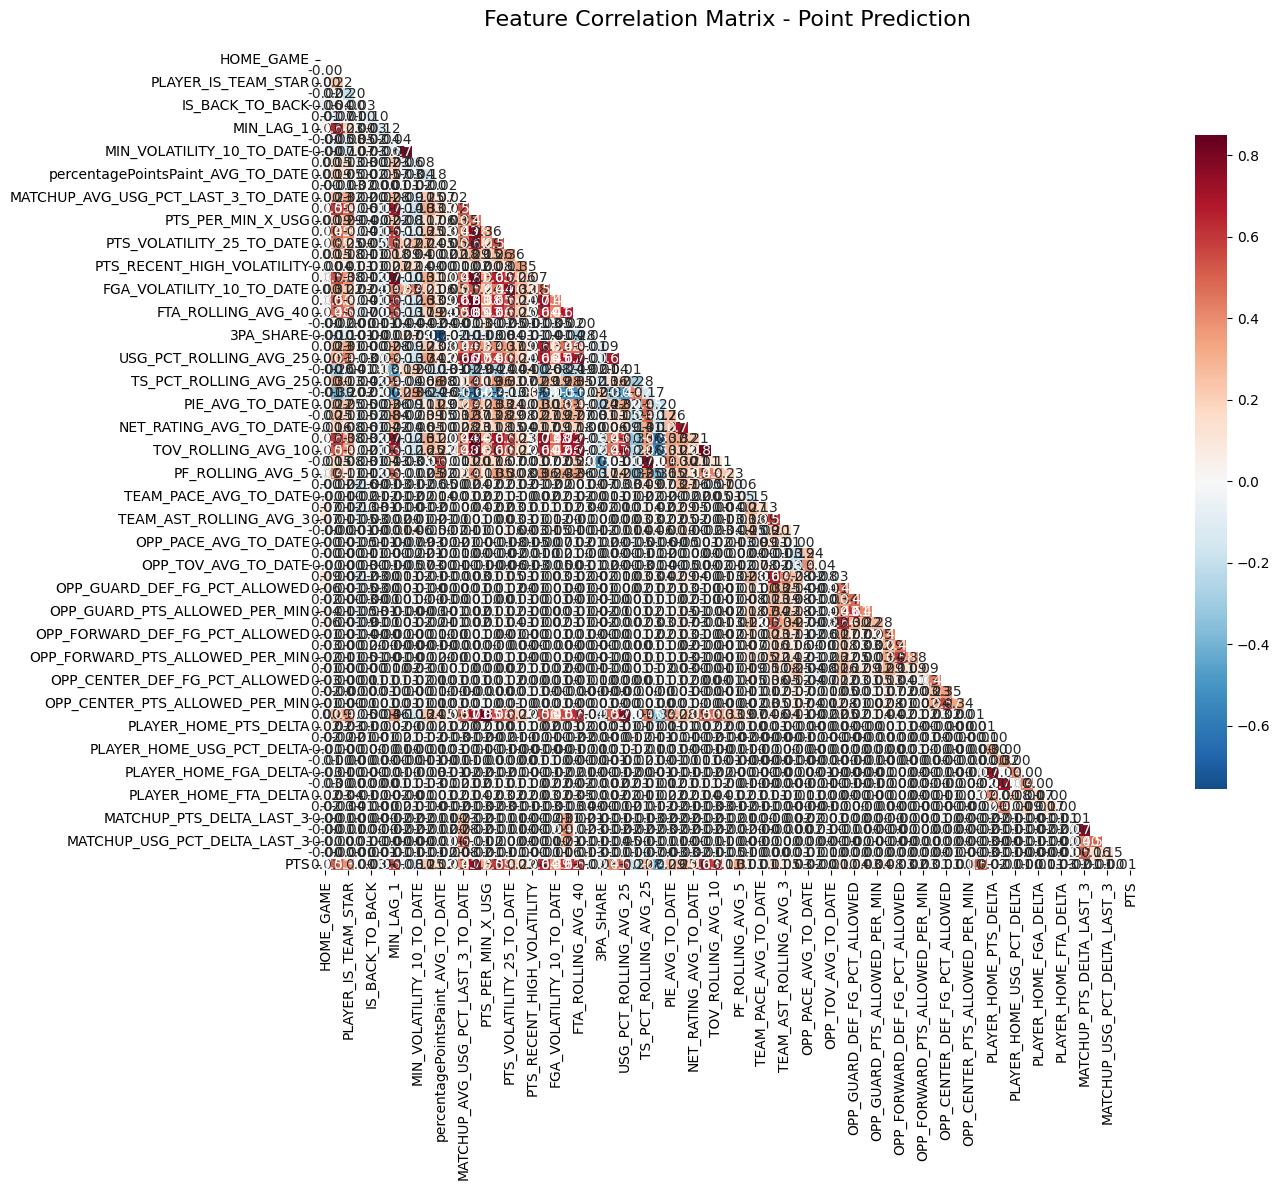

TOP 10 FEATURES MOST CORRELATED WITH PTS:
 1. PTS_ROLLING_AVG_25             0.720
 2. FGA_LAG_1                      0.636
 3. TCHS_ROLLING_AVG_10            0.626
 4. FTA_ROLLING_AVG_40             0.623
 5. MATCHUP_AVG_FGA_LAST_3_TO_DATE 0.616
 6. PTS_LAG_2                      0.586
 7. TOV_ROLLING_AVG_10             0.580
 8. USG_PCT_ROLLING_AVG_25         0.568
 9. MIN_LAG_1                      0.560
10. STARTING                       0.511

SUMMARY:
Original features: 70
Removed features: 0
Final features: 70


In [21]:
corr_matrix, top_10_features = correlation_analysis(train_df, top_features)

top_features = remove_highly_correlated_features(train_df, top_features, threshold=0.85)

### Train xgboost model and also using quantile regression

In [22]:
xgbModels, val_metrics = fit_quantile_models(
    train_df, val_df, 
    top_features, 
    'PTS', 
    'GAME_DATE', 
    'PLAYER_ID',
    recent_n=30, recent_weight=4.0, use_gpu=False, 
    tune_hyperparams=False, tune_iters=50)

# Make predictions with quantile models
# pred_df = predict_quantiles(xgbModels, test_df, top_features)

# Evaluate quantile models on test set
test_results = evaluate_quantile_models(xgbModels, test_df, top_features, 'PTS')

print("=" * 50)
print("QUANTILE REGRESSION VALIDATION RESULTS")
for quantile_name, results in val_metrics.items():
    print(f"{quantile_name} Val RMSE: {results['RMSE']:.3f}")
    print(f"{quantile_name} Val MAE: {results['MAE']:.3f}")
    print(f"{quantile_name} Val R²: {results['R2']:.3f}")

print("\n" + "=" * 50)
print("QUANTILE REGRESSION TEST RESULTS")
for quantile_name, results in test_results.items():
    print(f"{quantile_name} Test RMSE: {results['RMSE']:.3f}")
    print(f"{quantile_name} Test MAE: {results['MAE']:.3f}")
    print(f"{quantile_name} Test R²: {results['R2']:.3f}")


Training quantile model for q10...
q10 validation RMSE: 9.383

Training quantile model for q50...
q50 validation RMSE: 5.761

Training quantile model for q90...
q90 validation RMSE: 9.846
q10 Test RMSE: 9.576
q50 Test RMSE: 5.885
q90 Test RMSE: 10.195
QUANTILE REGRESSION VALIDATION RESULTS
q10 Val RMSE: 9.383
q10 Val MAE: 7.162
q10 Val R²: -0.130
q50 Val RMSE: 5.761
q50 Val MAE: 4.337
q50 Val R²: 0.574
q90 Val RMSE: 9.846
q90 Val MAE: 8.457
q90 Val R²: -0.244

QUANTILE REGRESSION TEST RESULTS
q10 Test RMSE: 9.576
q10 Test MAE: 7.356
q10 Test R²: -0.189
q50 Test RMSE: 5.885
q50 Test MAE: 4.443
q50 Test R²: 0.551
q90 Test RMSE: 10.195
q90 Test MAE: 8.756
q90 Test R²: -0.347


### Evaluate pinball loss on out-of-time data

In [23]:
validate_by_position_pinball_loss(xgbModels, test_df, top_features, 'PTS')

PINBALL LOSS BY POSITION

GUARD (n=7034):
  q10: 0.8821
  q50: 2.3275
  q90: 1.1799

FORWARD (n=5284):
  q10: 0.7838
  q50: 2.1208
  q90: 1.0933

CENTER (n=1366):
  q10: 0.7653
  q50: 2.0638
  q90: 1.0530


### Plot SHAP values per position to verify the model leans on the right drivers


Q10 MODEL:
------------------------------
Top 10 Features:
  PTS_ROLLING_AVG_25             1.7654
  STARTING                       0.9394
  FGA_LAG_1                      0.2625
  MIN_LAG_1                      0.2428
  TEAM_PTS_ROLLING_AVG_3         0.1689
  TCHS_ROLLING_AVG_10            0.1583
  OPP_GUARD_DEF_RATING           0.1443
  PTS_LAG_2                      0.1190
  FTA_ROLLING_AVG_40             0.1126
  PTS_PER_MIN_X_USG              0.1095
  PTS_PER_MIN_X_OPP_DEF_RATING   0.0905
  USG_PCT_ROLLING_AVG_25         0.0684
  PLAYER_IS_TEAM_STAR            0.0658
  OPP_FORWARD_DEF_RATING         0.0532
  3PA_SHARE                      0.0512

By Position:
  GUARD (n=7034): PTS_ROLLING_AVG_25 (1.899)
  FORWARD (n=5284): PTS_ROLLING_AVG_25 (1.655)
  CENTER (n=1366): PTS_ROLLING_AVG_25 (1.502)


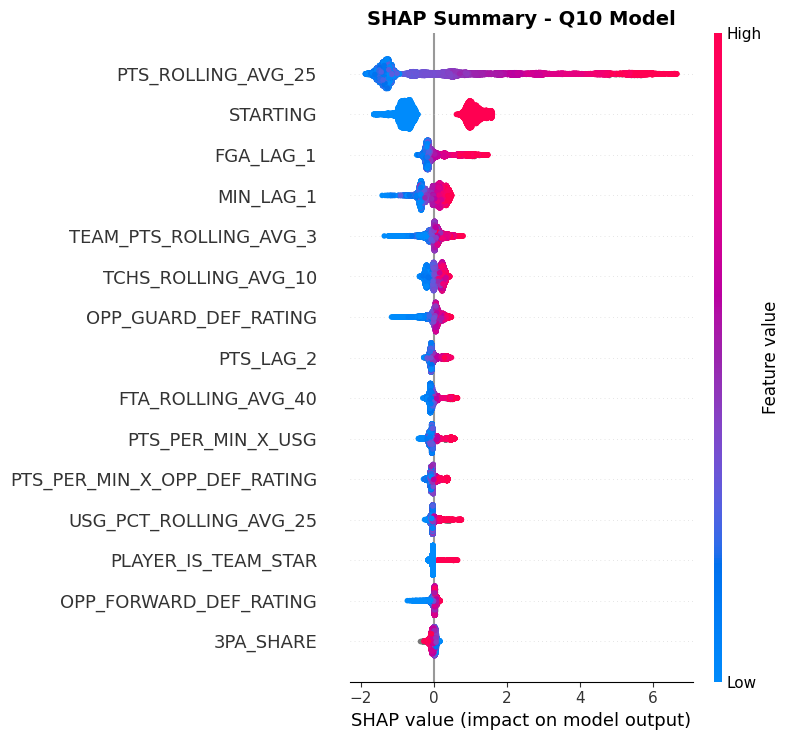


Q50 MODEL:
------------------------------
Top 10 Features:
  PTS_ROLLING_AVG_25             2.7429
  STARTING                       1.3937
  MIN_LAG_1                      0.4292
  FGA_LAG_1                      0.3722
  STAR_SAT_OUT                   0.3468
  TEAM_PTS_ROLLING_AVG_3         0.3334
  USG_PCT_ROLLING_AVG_25         0.2553
  PTS_PER_MIN_X_USG              0.2465
  OPP_GUARD_DEF_RATING           0.2377
  MATCHUP_AVG_FGA_LAST_3_TO_DATE 0.2180
  TCHS_ROLLING_AVG_10            0.1917
  PTS_LAG_2                      0.1705
  PTS_DELTA_STAR_OUT             0.1464
  PTS_PER_MIN_X_OPP_DEF_RATING   0.1430
  TEAM_AST_ROLLING_AVG_3         0.1118

By Position:
  GUARD (n=7034): PTS_ROLLING_AVG_25 (2.918)
  FORWARD (n=5284): PTS_ROLLING_AVG_25 (2.594)
  CENTER (n=1366): PTS_ROLLING_AVG_25 (2.420)


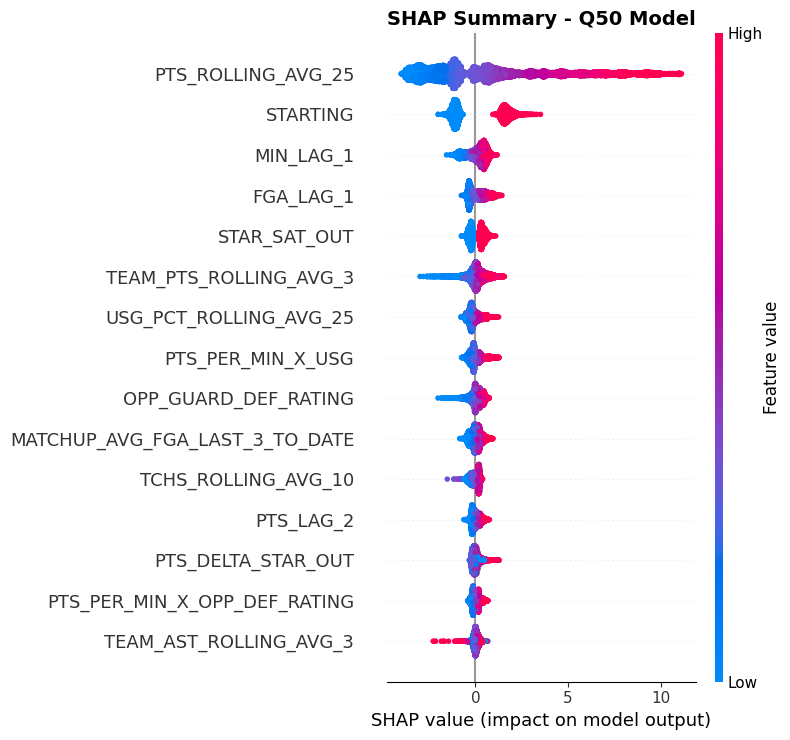


Q90 MODEL:
------------------------------
Top 10 Features:
  PTS_ROLLING_AVG_25             3.4084
  STARTING                       1.4700
  FGA_LAG_1                      0.9199
  TEAM_PTS_ROLLING_AVG_3         0.5926
  STAR_SAT_OUT                   0.5732
  MIN_LAG_1                      0.3349
  USG_PCT_ROLLING_AVG_25         0.3279
  OPP_GUARD_DEF_RATING           0.2985
  MATCHUP_AVG_FGA_LAST_3_TO_DATE 0.2654
  PTS_PER_MIN_X_USG              0.2604
  PTS_VOLATILITY_25_TO_DATE      0.2559
  PTS_LAG_2                      0.2393
  PTS_DELTA_STAR_OUT             0.2086
  FG_PCT_AVG_TO_DATE             0.1316
  PLAYER_DAYS_REST               0.1265

By Position:
  GUARD (n=7034): PTS_ROLLING_AVG_25 (3.584)
  FORWARD (n=5284): PTS_ROLLING_AVG_25 (3.291)
  CENTER (n=1366): PTS_ROLLING_AVG_25 (2.957)


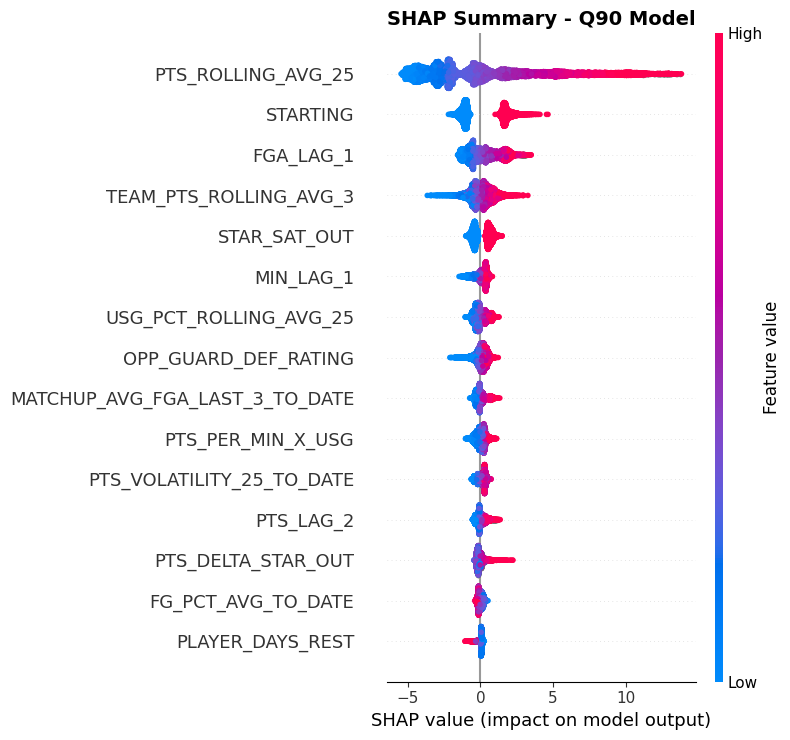

{'q10': XGBRegressor(base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='quantile',
              feature_types=None, feature_weights=None, gamma=1.0,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None, max_delta_step=0,
              max_depth=6, max_leaves=None, min_child_weight=2, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1072,
              n_jobs=-1, num_parallel_tree=None, ...),
 'q50': XGBRegressor(base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6460723242676091, device=None,
              early_stopping_rounds=N

In [24]:
analyze_quantile_shap(xgbModels, test_df, top_features, 'PTS')

### Check top 20 highest residuals

In [25]:
residuals_df = get_quantile_residuals(xgbModels, test_df, top_features, 'PTS')
residuals_df.sort_values('residual_q50', ascending=False).head(10)

,actual,pred_q10,pred_q50,pred_q90,residual_q10,residual_q50,residual_q90,PLAYER_NAME,MATCHUP,TEAM_PTS,OPP_PTS,STARTING,MIN,GUARD,FORWARD,CENTER,interval_width,within_80_interval,within_50_interval
5912,43,1.484093,7.647308,15.536710,41.515907,35.352692,27.463290,Nikola Jokić,DEN vs. WAS,123.0,126.0,1.0,39.22,0.0,0.0,1.0,14.052617,False,False
2819,55,10.913427,20.330187,32.528072,44.086573,34.669813,22.471928,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.614645,False,False
3031,61,17.526930,28.342710,37.994797,43.473070,32.657290,23.005203,Yves Missi,NOP @ MEM,126.0,139.0,1.0,29.58,0.0,0.0,1.0,20.467867,False,False
668,43,2.900406,10.598144,20.919056,40.099594,32.401856,22.080944,Georges Niang,ATL @ CHA,134.0,102.0,0.0,23.97,0.0,1.0,0.0,18.018650,False,False
5442,41,2.000863,8.703391,18.847456,38.999137,32.296609,22.152544,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.846594,False,False
10541,41,2.786333,9.445148,18.677261,38.213667,31.554852,22.322739,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.890928,False,False
3327,56,12.892423,24.714882,37.585648,43.107577,31.285118,18.414352,Elfrid Payton,NOP vs. CHA,98.0,94.0,0.0,19.30,1.0,0.0,0.0,24.693226,False,False
8351,44,4.214865,12.783120,24.775024,39.785135,31.216880,19.224976,Nicolas Batum,LAC vs. WAS,110.0,93.0,0.0,12.22,1.0,0.0,0.0,20.560160,False,False
10312,34,0.083694,6.323438,14.743130,33.916306,27.676562,19.256870,Andrew Wiggins,MIA vs. CHA,122.0,105.0,1.0,35.22,0.0,1.0,0.0,14.659436,False,False
8440,46,9.174407,18.836649,33.588684,36.825593,27.163351,12.411316,Amir Coffey,LAC vs. MEM,128.0,114.0,0.0,18.30,1.0,0.0,0.0,24.414276,False,False


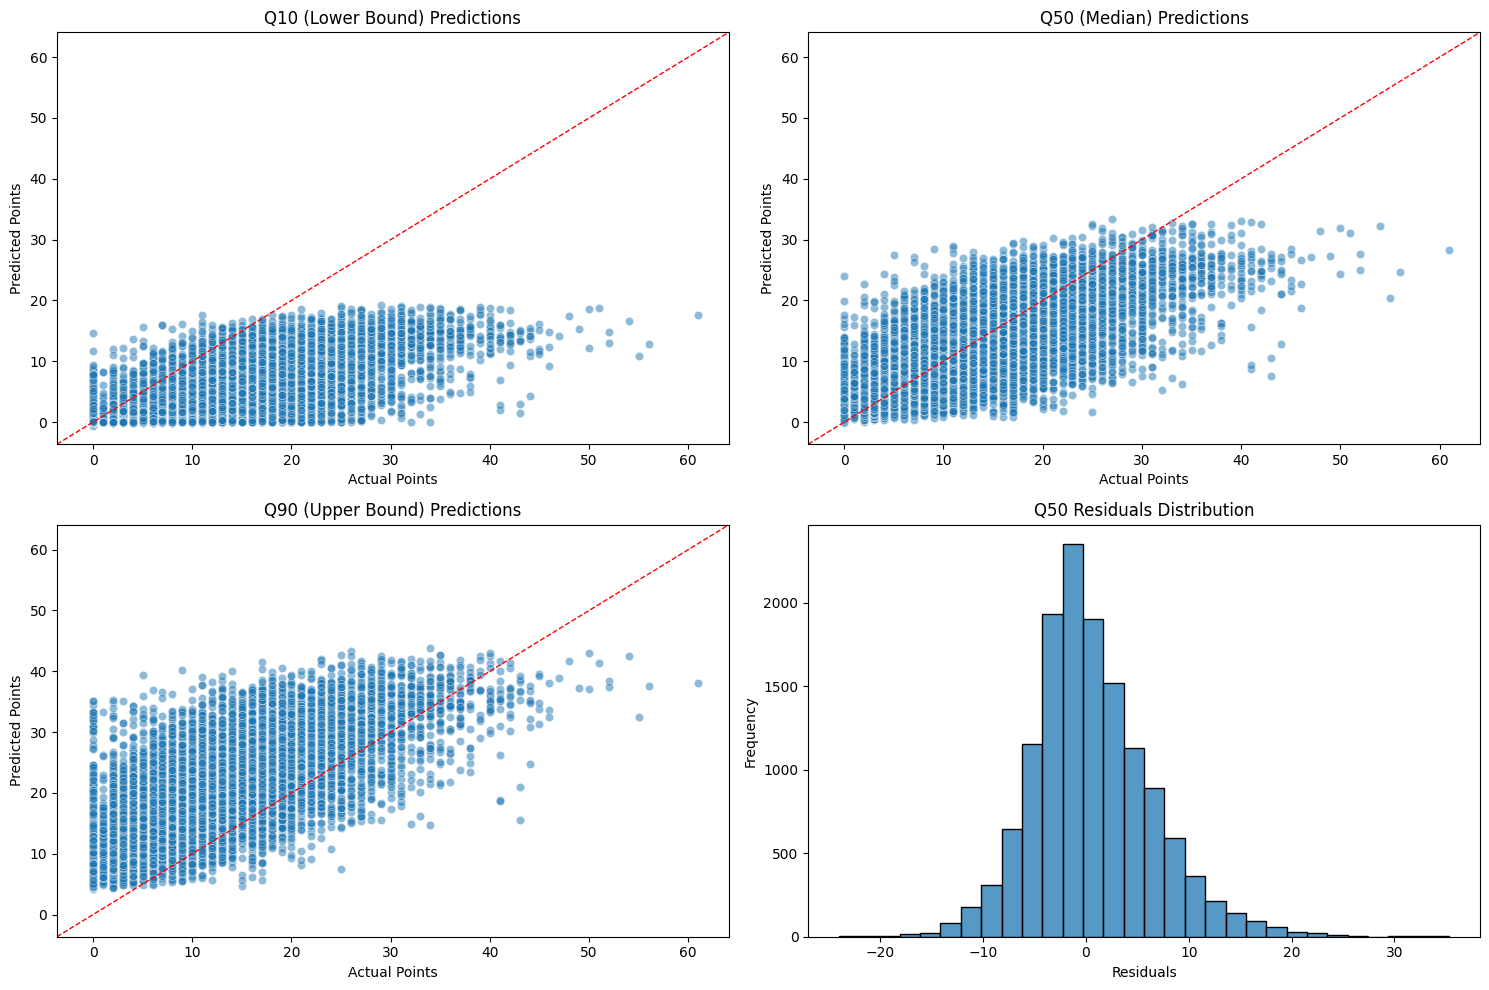

In [26]:
# Enhanced quantile prediction plot
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Q10 predictions
sns.scatterplot(x='actual', y='pred_q10', data=residuals_df, alpha=0.5, ax=axes[0,0])
minVal = min(residuals_df['actual'].min(), residuals_df['pred_q10'].min())
maxVal = max(residuals_df['actual'].max(), residuals_df['pred_q10'].max())
axes[0,0].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,0].set_title('Q10 (Lower Bound) Predictions')
axes[0,0].set_xlabel('Actual Points')
axes[0,0].set_ylabel('Predicted Points')

# Q50 predictions  
sns.scatterplot(x='actual', y='pred_q50', data=residuals_df, alpha=0.5, ax=axes[0,1])
minVal = min(residuals_df['actual'].min(), residuals_df['pred_q10'].min())
maxVal = max(residuals_df['actual'].max(), residuals_df['pred_q10'].max())
axes[0,1].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,1].set_title('Q50 (Median) Predictions')
axes[0,1].set_xlabel('Actual Points')
axes[0,1].set_ylabel('Predicted Points')

# Q90 predictions
sns.scatterplot(x='actual', y='pred_q90', data=residuals_df, alpha=0.5, ax=axes[1,0])
minVal = min(residuals_df['actual'].min(), residuals_df['pred_q10'].min())
maxVal = max(residuals_df['actual'].max(), residuals_df['pred_q10'].max())
axes[1,0].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[1,0].set_title('Q90 (Upper Bound) Predictions')
axes[1,0].set_xlabel('Actual Points')
axes[1,0].set_ylabel('Predicted Points')

# Residuals distribution
sns.histplot(residuals_df['residual_q50'], bins=30, ax=axes[1,1])
axes[1,1].set_title('Q50 Residuals Distribution')
axes[1,1].set_xlabel('Residuals')
axes[1,1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

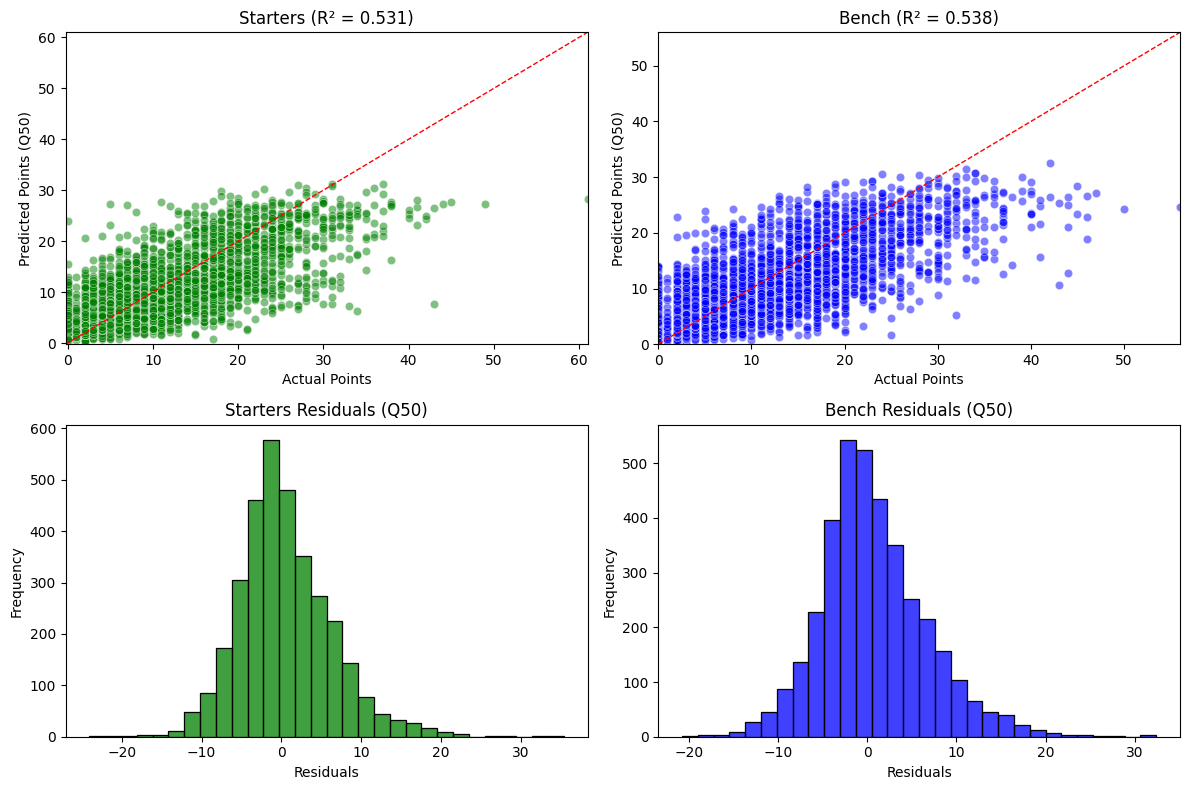

In [27]:
# Get quantile residuals first
residuals_df = get_quantile_residuals(xgbModels, test_df, top_features, 'PTS')

# Split by starting status
starters = residuals_df[residuals_df['STARTING'] == 1] 
bench = residuals_df[residuals_df['STARTING'] == 0]

# Calculate R² for Q50 (median) predictions
from sklearn.metrics import r2_score
starters_r2 = r2_score(starters['actual'], starters['pred_q50'])
bench_r2 = r2_score(bench['actual'], bench['pred_q50'])

fig, axes = plt.subplots(2, 2, figsize=(12, 8)) 

# Starters scatter plot
sns.scatterplot(x='actual', y='pred_q50', data=starters, color='green', alpha=0.5, ax=axes[0,0])
minVal = min(starters['actual'].min(), starters['pred_q50'].min())
maxVal = max(starters['actual'].max(), starters['pred_q50'].max())
axes[0,0].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,0].set_xlim(minVal, maxVal)
axes[0,0].set_ylim(minVal, maxVal)
axes[0,0].set_title(f'Starters (R² = {starters_r2:.3f})')
axes[0,0].set_xlabel('Actual Points')
axes[0,0].set_ylabel('Predicted Points (Q50)')

# Bench scatter plot
sns.scatterplot(x='actual', y='pred_q50', data=bench, color='blue', alpha=0.5, ax=axes[0,1])
minVal = min(bench['actual'].min(), bench['pred_q50'].min())
maxVal = max(bench['actual'].max(), bench['pred_q50'].max())
axes[0,1].axline(xy1=(minVal, minVal), xy2=(maxVal, maxVal), color='red', linewidth=1, linestyle='--')
axes[0,1].set_xlim(minVal, maxVal)
axes[0,1].set_ylim(minVal, maxVal)
axes[0,1].set_title(f'Bench (R² = {bench_r2:.3f})')
axes[0,1].set_xlabel('Actual Points')
axes[0,1].set_ylabel('Predicted Points (Q50)')

# Starters residuals
sns.histplot(starters['residual_q50'], bins=30, color='green', ax=axes[1,0])
axes[1,0].set_title('Starters Residuals (Q50)')
axes[1,0].set_xlabel('Residuals')
axes[1,0].set_ylabel('Frequency')

# Bench residuals
sns.histplot(bench['residual_q50'], bins=30, color='blue', ax=axes[1,1])
axes[1,1].set_title('Bench Residuals (Q50)')
axes[1,1].set_xlabel('Residuals')
axes[1,1].set_ylabel('Frequency')

plt.tight_layout()  
plt.show()

In [28]:
joblib.dump(xgbModels['q10'], 'SAVED_MODELS/xgb_q10_modelv2.pkl')
joblib.dump(xgbModels['q50'], 'SAVED_MODELS/xgb_q50_modelv2.pkl')
joblib.dump(xgbModels['q90'], 'SAVED_MODELS/xgb_q90_modelv2.pkl')
joblib.dump(top_features, 'SAVED_MODELS/feature_list.pkl')

['SAVED_MODELS/feature_list.pkl']